In [4]:
import pandas as pd
import json
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import requests as rq
from tqdm import tqdm
tqdm.pandas()  # Initialize tqdm for pandas

plt.rcParams['font.family'] = 'Roboto Condensed'
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titlelocation'] = 'left'

def get_dossier_id(kst_id):
    try:
        u = f"https://gegevensmagazijn.tweedekamer.nl/OData/v4/2.0/document?$filter=Id eq {kst_id}&expand=Kamerstukdossier"
        c = rq.get(u).json()
        c = c['value'][0]['Kamerstukdossier'][0]['Nummer']
        return c
    except:
        return

# --- Load metadata first ---
with open('data/meta-kst.json', 'r') as f:
    mtdkst = json.load(f)

with open('data/meta-reports.json', 'r') as f:
    mtdrep = json.load(f)

In [5]:
df = pd.read_csv('results/matches-rep-kst-chunks.csv')

df['report_title'] = df.query_id.map({m['_id']:m['title'] for m in mtdrep})
df['report_cat'] = df.query_id.map({m['_id']:m['category'] for m in mtdrep})

df['kst_title'] = df.target_id.map({m['id_']:m['source_title'] for m in mtdkst})

AttributeError: 'DataFrame' object has no attribute 'query_id'

In [ ]:
df['tk_chunk_text'][110331], df['rep_chunk_text'][110331]

('Het kabinet houdt ook bij toekomstige verzoeken aandacht voor de effecten op de gereedheid. Europese Vredesfaciliteit Vanuit de Europese Vredesfaciliteit (European Peace Facility – EPF) is momenteel 3,5 miljard euro beschikbaar gesteld als compensatie voor levering van militair materieel vanuit de EU-lidstaten aan Oekraïne. Daarnaast is 1 miljard euro gealloceerd voor de levering van munitie uit eigen voorraden en nog eens 1 miljard voor de gezamenlijke aanschaf van munitie bij de Europese industrie. Tot en met februari 2023 heeft Nederland voor ongeveer 462 miljoen euro aan prioritaire leveringen gedeclareerd.',
 'Er is daarnaast voor € 775 miljoen aan militair materieel geleverd aan Oekraïne dat aangekocht is. Voor leveringen uit eigen voorraad tot en met februari 2023 heeft Defensie € 462 miljoen gedeclareerd. Hiervan zal Defensie € 242 miljoen van de Europese Vredesfaciliteit (EPF) ontvangen, deze ontvangsten worden in 2024 verwacht. Daarbovenop heeft Defensie over leveringen uit

In [11]:
df[df.score>.7]

,score,rep_chunk_text,rep_sentence_indices,tk_chunk_text,tk_sentence_indices
39,0.702570,Momenteel vindt daarom bij het WODC uitbouw pl...,"[246, 247, 248, 249]",Dit vergt een informatievoorziening die dergel...,"[1093623, 1093624, 1093625, 1093626]"
2782,0.836142,We zullen de door u gehoorde persoon met een a...,"[5862, 5863, 5864, 5865]","Den Haag, 13 mei 2014 Met deze brief willen we...","[4045287, 4045288, 4045289, 4045290]"
2783,0.775241,Het is dus van groot belang dat het systeem va...,"[5865, 5866, 5867, 5868]",Het is dus van groot belang dat het systeem va...,"[4045290, 4045291, 4045292, 4045293]"
4502,0.713887,Deze rijksbijdrage is bedoeld om de verwachte ...,"[7995, 7996, 7997, 7998]",De leden van de PVV-fractie vinden het bizar d...,"[5155881, 5155882, 5155883, 5155884]"
5596,0.747210,Een afweging per geval moet de mogelijkheid op...,"[9360, 9361, 9362, 9363]",Het is een goed idee om een plan en een tijdsp...,"[3616419, 3616420, 3616421, 3616422]"
...,...,...,...,...,...
104183,0.702076,Zoals wij ook in voorgaande jaren constateerde...,"[153291, 153292, 153293, 153294]",Defensie is daarmee het departement met de mee...,"[7512816, 7512817, 7512818, 7512819]"
106024,0.721138,Arbeidsongevallen die niet gemeld worden vorme...,"[155748, 155749, 155750, 155751]",Toezicht en handhaving op de naleving van de A...,"[1666737, 1666738, 1666739, 1666740]"
110331,0.705166,Er is daarnaast voor € 775 miljoen aan militai...,"[158583, 158584, 158585, 158586]",Het kabinet houdt ook bij toekomstige verzoeke...,"[3328584, 3328585, 3328586, 3328587]"
116913,0.744726,3.1.3 Gevolgen beleidswijziging voor mensen me...,"[165561, 165562, 165563, 165564]",Gemeenten zijn door deze wet verantwoordelijk ...,"[1798221, 1798222, 1798223, 1798224]"


In [80]:
dossiers = pd.read_csv('metadata/dossiers.csv').dropna(subset=['Nummer'])

In [81]:
df['dossier'] = df['target_id'].str.split(':').str[1].progress_apply(get_dossier_id)

100%|██████████| 1234/1234 [01:42<00:00, 12.07it/s]


In [83]:
df.dossier.map(dict(zip(dossiers.Nummer.astype(int),dossiers.Titel))).value_counts()

dossier
Raad voor Vervoer, Telecommunicatie en Energie                                                                                                                                                                                                          79
Programma doorontwikkeling F-35                                                                                                                                                                                                                         42
Verbetering verantwoording en begroting                                                                                                                                                                                                                 36
Jaarverslag en slotwet overige Hoge Colleges van Staat en de Kabinetten van de Gouverneurs 2016                                                                                                                                                

**Diachronic**

In [27]:
df = df.sort_values('similarity').drop_duplicates('query_sent',keep='last')

In [31]:
df.groupby('report_title').size().nlargest()

report_title
Aanpak van laaggeletterdheid                                    14
Kunnen basisscholen passend onderwijs aan?                      14
Monitoring vervanging F-16                                      13
Rijksoverheid en Caribisch Nederland: naleving van afspraken    12
Informatievoorziening grote projecten                           10
dtype: int64

**Explore High Matches**

In [ ]:
dff = df[~df.kst_title.astype(str).str.lower().str.contains('jaarverslag') &
         ~df.target_sent.str.contains('Reken') &
         ~df.target_sent.str.contains('inzake') &
         (df.month_diff<48) &
         (df.similarity < .85)]

dff = dff[['query_sent','target_sent','similarity','report_title','kst_title']].sort_values('similarity').drop_duplicates(subset=['query_sent'],keep='last')

In [11]:
dff.nlargest(5,'similarity')

,query_sent,target_sent,similarity,report_title,kst_title
821,Ze hebben toegang tot gevoelige informatie of ...,Zij hebben toegang tot gevoelige informatie of...,0.849068,Rapport bij het Jaarverslag 2011 van het Minis...,Toezichtsverslagen AIVD en MIVD
852,Als we meer inzicht willen hebben in de bested...,Als wij meer inzicht willen hebben in de beste...,0.842037,Geldstromen in het hoger beroepsonderwijs in 2010,Beroepsonderwijs en Volwassenen Educatie
799,Projectdefinitie Vervanging F-16 in Jaarrappor...,Het project Vervanging F-16 betreft een niet-g...,0.787334,Monitoring vervanging F-16,Behoeftestelling vervanging F-16
937,Voor ‘materieel’ is in 2006 voor het laatst be...,In 2006 is voor het laatst bekeken of de grond...,0.763504,Kunnen basisscholen passend onderwijs aan?,Primair Onderwijs
719,Het kabinet wil toe naar één regeling voor de ...,"De VVD wil daarom de WWB, de Wet werk en arbei...",0.759406,Aanpak harde kern jeugdwerklozen - Terugblik,Arbeidsmarktbeleid


In [15]:
i = 937
df.loc[i], df.target_sent[i], df.query_sent[i], df.target_id[i]

(query_id              rekenkamer__rapport:2013:07:02:kunnen-basissch...
 query_sent            Voor ‘materieel’ is in 2006 voor het laatst be...
 query_date                                                   2013-07-02
 query_averageness                                              0.059803
 target_id             kamerstukken__algemeen_overleg:d921588f-6d65-4...
 target_sent           In 2006 is voor het laatst bekeken of de grond...
 target_date                                                  2013-10-01
 target_averageness                                            -0.005922
 similarity                                                     0.763504
 month_diff                                                            3
 kst_type                                               algemeen_overleg
 mdr                                                                   0
 report_title                 Kunnen basisscholen passend onderwijs aan?
 report_cat                                        

In [19]:
df.target_id[i].split(':')[-1]

'd921588f-6d65-435b-bf27-f90532f69e2e'

In [13]:
[m for m in mtdrep if 'ort:2013:07:02:kunnen-basi' in m['_id']]

[{'title': 'Kunnen basisscholen passend onderwijs aan?',
  'link': 'https://www.rekenkamer.nl/publicaties/rapporten/2013/07/02/kunnen-basisscholen-passend-onderwijs-aan',
  'description': '‘Passend onderwijs’ moet ervoor zorgen dat kwetsbare leerlingen in het basisonderwijs een plek krijgen die zo goed mogelijk bij ...',
  'date': 'Rapport | 02-07-2013',
  '_id': 'rekenkamer__rapport:2013:07:02:kunnen-basisscholen-passend-onderwijs-aan',
  'category': 'OCW'}]

In [14]:
[m for m in mtdkst if 'en_overleg:d921588f-6d65' in m['id_']]

[{'detail_url': 'https://www.tweedekamer.nl/kamerstukken/detail?id=2013Z13744&did=2013D36188',
  'sub_source': 'Verslag van een algemeen overleg',
  'source_title': 'Primair Onderwijs',
  'source_subject': 'Verslag van een algemeen overleg, gehouden op 4 september 2013, over Financiën primair onderwijs',
  'case': [{'title': 'Primair Onderwijs',
    'number': '2013Z13744',
    'start_date': '2013-06-28T00:00:00+02:00'}],
  'actor': [{'person_id': '9c4710f5-fb0b-42cc-9d53-4cf5dfe6e27c',
    'fraction_id': '8d46d23c-4f20-49be-b279-5439a2ef8d17',
    'name': 'A.G. Wolbert',
    'faction': 'PvdA',
    'role': 'voorzitter van de vaste commissie voor Onderwijs, Cultuur en Wetenschap'},
   {'person_id': '81d55647-7d41-49f8-a929-b52407d16e55',
    'fraction_id': None,
    'name': 'E.C.E. de Kler',
    'faction': None,
    'role': 'griffier'}],
  'dossier': [{'id': '49346c17-73f4-408e-8558-759c4616cd22',
    'title': 'Primair Onderwijs',
    'nummer': 31293}],
  'page_count': 40,
  'unmapped_ch

**Scores over time**

In [21]:
df['query_year'] = pd.to_datetime(df.query_date).dt.year
df['target_year'] = pd.to_datetime(df.target_date).dt.year

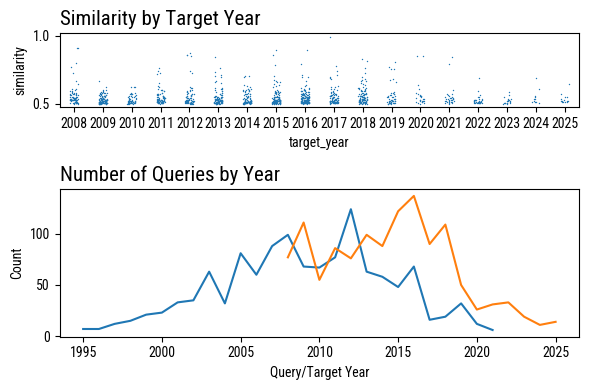

In [22]:
# ✅ Fixed: Only 2 rows in GridSpec, matching the 2 height ratios
fig = plt.figure(figsize=(6, 4))
gs = GridSpec(2, 1, height_ratios=[1, 2], figure=fig)

# --- Top: jitter plot ---
ax_top = fig.add_subplot(gs[0, 0])
sns.stripplot(
    data=df,
    x='target_year',
    y='similarity',
    jitter=0.15,
    size=1,
    ax=ax_top
)
ax_top.set_title("Similarity by Target Year")
# ax_top.set_xlim(1995,2025)

# --- Bottom: line plot ---
ax_bottom = fig.add_subplot(gs[1, 0])
df.groupby('query_year').size().plot(ax=ax_bottom)
df.groupby('target_year').size().plot(ax=ax_bottom)

ax_bottom.set_title("Number of Queries by Year")
ax_bottom.set_xlabel("Query/Target Year")
ax_bottom.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Scores by Category**

In [23]:
n_report_by_cat = pd.Series([m['category'] for m in mtdrep]).value_counts(normalize=True)
n_report_match_by_cat = df.report_cat.value_counts(normalize=True)

In [24]:
norm_cat = n_report_match_by_cat / n_report_match_by_cat.index.map(n_report_by_cat)

<Axes: title={'left': 'Ratio of Matches / Number of Reports\nby Department'}, ylabel='report_cat'>

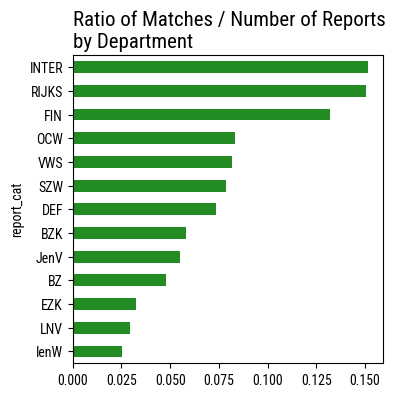

In [25]:
n_report_match_by_cat.sort_values().plot(kind='barh',
                            title='Ratio of Matches / Number of Reports\nby Department',
                            figsize=(4,4),
                            color='forestgreen')

<Axes: xlabel='query_date'>

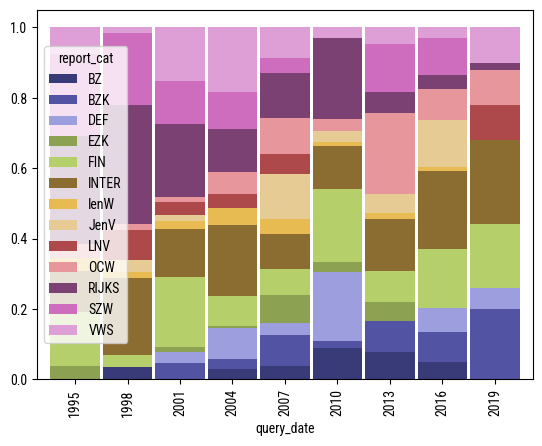

In [26]:
# Over time
df.groupby(pd.to_datetime(df.query_date).dt.year // 3 * 3)\
    .apply(lambda x: x.report_cat.value_counts(normalize=True))\
    .unstack()\
    .plot(kind='bar',
          width=.95,
          stacked=True,
          cmap='tab20b')

In [38]:
df.nlargest(15,'similarity')[['query_sent','target_sent','month_diff']]

,query_sent,target_sent,month_diff
1136,"Het ontbreken van voldoende, tijdige en goede ...",Het ontbreken van voldoende tijdige en goede b...,12
541,Bij deze te complexe projecten is er geen bala...,Volgens de Algemene Rekenkamer is er bij deze ...,2
457,Bij deze te complexe projecten is er geen bala...,Volgens de Algemene Rekenkamer is er bij deze ...,10
735,Naast de verwerving van de jachtvliegtuigen ze...,Naast de verwerving van jachtvliegtuigen omvat...,49
1085,De ontoereikendheid van de materiële bekostigi...,De Rekenkamer schrijft: «De ontoereikendheid v...,4
810,Ze hebben toegang tot gevoelige informatie of ...,Zij hebben toegang tot gevoelige informatie of...,2
811,Om er zeker van te zijn dat mensen in vertrouw...,Om er zeker van te zijn dat mensen in vertrouw...,2
822,Om er zeker van te zijn dat mensen in vertrouw...,Om er zeker van te zijn dat mensen in vertrouw...,2
801,Naast de verwerving van jacht- vliegtuigen omv...,Naast de verwerving van jachtvliegtuigen omvat...,36
1206,Daarvoor is een wet- en regelgevingspraktijk n...,De Rekenkamer geeft aan dat regelgeving nodig ...,7


In [42]:
[m for m in mtdkst if '0b7e4c47-2bd4' in m['id_']]

[{'detail_url': 'https://www.tweedekamer.nl/kamerstukken/detail?id=2014Z23160&did=2015D09294',
  'sub_source': 'Verslag van een algemeen overleg',
  'source_title': 'Behoeftestelling vervanging F-16',
  'source_subject': 'Verslag van een algemeen overleg, gehouden op 26 februari 2015, over DMP-D vervanging F-16',
  'case': [{'title': 'Behoeftestelling vervanging F-16',
    'number': '2014Z23160',
    'start_date': '2014-12-15T00:00:00+01:00'}],
  'actor': [{'person_id': 'aa316142-d6ee-4138-bf48-37cd7d11d058',
    'fraction_id': '8d46d23c-4f20-49be-b279-5439a2ef8d17',
    'name': 'R.A. Vermeij',
    'faction': 'PvdA',
    'role': 'voorzitter van de vaste commissie voor Economische Zaken'},
   {'person_id': '15a02ea4-c9ae-483a-b01f-5cf8e19e7c75',
    'fraction_id': None,
    'name': 'G.F.C. van Leiden',
    'faction': None,
    'role': 'griffier'},
   {'person_id': '3dbbf804-bad5-44f2-b8c7-091baf63758d',
    'fraction_id': '7476e97a-3243-4122-9df6-ba7d82a5279b',
    'name': 'J.H. ten Bro

In [47]:
d = get_dossier_documents(df.target_id[i].split(':')[-1])

In [50]:
d[d.Soort.str.contains('Rekenkamer')]

,Id,Soort,DocumentNummer,Titel,Onderwerp,Datum,Vergaderjaar,Kamer,Volgnummer,Citeertitel,...,DatumOntvangst,Aanhangselnummer,KenmerkAfzender,Organisatie,ContentType,ContentLength,GewijzigdOp,ApiGewijzigdOp,Verwijderd,HuidigeDocumentVersie_Id
16,4da5e1f9-510d-4e20-a062-05a60d4372b3,Brief Algemene Rekenkamer,2014D04049,Primair Onderwijs,Beantwoording van de vraag bij de brief ‘Aanda...,2014-02-04,2013-2014,2,198,None,...,2014-02-05T00:00:00+01:00,None,None,Tweede Kamer,application/pdf,211181,2024-02-19T10:56:03.63+01:00,2024-02-22T02:18:08.8622411Z,False,02d139ea-d7fb-427e-aab5-d0371762d564
134,dee1420a-e3dc-4f00-a27f-289b9626c404,Brief Algemene Rekenkamer,2015D21134,Primair Onderwijs,Aanbieding van het rapport van de Algemene Rek...,2015-06-04,2014-2015,2,260,None,...,2015-06-04T00:00:00+02:00,None,None,Tweede Kamer,application/pdf,24574,2024-02-19T10:56:03.63+01:00,2024-02-22T17:01:27.0700033Z,False,30dacb0e-03b4-444f-9cdb-4786989cf496


,Id,Soort,DocumentNummer,Titel,Onderwerp,Datum,Vergaderjaar,Kamer,Volgnummer,Citeertitel,...,DatumOntvangst,Aanhangselnummer,KenmerkAfzender,Organisatie,ContentType,ContentLength,GewijzigdOp,ApiGewijzigdOp,Verwijderd,HuidigeDocumentVersie_Id
63,83d4ad7b-3ccf-4763-83f7-14563c00e815,Brief regering,2008D00937,Primair Onderwijs,Voortgang Kwaliteitsagenda Primair Onderwijs\n,2008-07-07,2007-2008,2,18,None,...,None,None,None,Tweede Kamer,application/pdf,77766,2024-02-19T10:56:03.63+01:00,2024-02-20T17:05:22.2619546Z,False,93ee4694-0c77-4ff2-a3e6-383daa926071
82,87a9e098-e88a-4891-8621-1a1d2f466087,Brief regering,2008D01734,Primair Onderwijs,Jaarverslagen 2006 in het primair onderwijs,2008-09-01,2007-2008,2,21,None,...,None,None,None,Tweede Kamer,application/pdf,33836,2024-02-19T10:56:03.63+01:00,2024-02-21T21:23:53.1538696Z,False,4a8280d7-caec-4df6-9e82-0d25581ca32c
235,5c253b21-39a9-4c52-b69c-4c889c3b3759,Brief regering,2008D19762,Primair Onderwijs,'Aanpak Opbrengstgericht Leiderschap',2008-12-03,2008-2009,2,32,None,...,2009-03-31T00:00:00+02:00,None,None,Tweede Kamer,application/pdf,32927,2024-02-19T10:56:03.63+01:00,2024-02-21T07:39:48.2397284Z,False,242865a7-f617-44fb-b63e-4ca544c5ec95
183,74dff318-8db0-4f1e-94ce-38f2a155c0b2,Verslag van een algemeen overleg,2008D23974,Primair Onderwijs,Verslag van een algemeen overleg over o.a. de ...,2008-12-23,2008-2009,2,24,None,...,None,None,None,Tweede Kamer,application/pdf,134634,2024-02-19T10:56:03.63+01:00,2024-02-21T06:31:09.7138844Z,False,04e237eb-9958-4f4b-82b4-0798e28449f3
51,03ef4f2b-dbfa-47d0-9c88-105920b5e788,Brief regering,2009D04782,Primair Onderwijs,Jaarverslagen in het Primair Onderwijs,2009-02-04,2008-2009,2,26,None,...,2009-02-05T00:00:00+01:00,None,None,Tweede Kamer,application/pdf,31443,2024-02-19T10:56:03.63+01:00,2024-02-20T16:53:50.7549709Z,False,b9f29428-004b-4ef1-84bd-a7df1a79a345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,35d98b78-614f-49f4-9cbf-317e261ebedb,Brief regering,2025D31120,Primair Onderwijs,Resultaten doorstroomtoetsen en schooladviezen...,2025-07-01,2024-2025,2,829,None,...,2025-07-04T00:00:00+02:00,None,None,Tweede Kamer,application/pdf,37546,2025-08-18T12:49:27.127+02:00,2025-08-18T10:49:47.2791694Z,False,665182b2-54bc-47fc-bb5c-9d7dda154c27
29,2ec514f1-421c-4a72-8f7a-0abe35e29f55,Motie,2025D38554,Primair Onderwijs,Motie van het lid Oostenbrink over het schoola...,2025-09-11,2024-2025,2,835,None,...,None,None,None,Tweede Kamer,application/pdf,20398,2025-09-12T15:41:21.583+02:00,2025-09-12T13:41:45.4134494Z,False,34b4f8fb-92a6-43e5-bf23-36b8c785d5d4
215,cdae19f8-434c-42de-b043-45fef4435dc8,Motie,2025D38578,Primair Onderwijs,Motie van de leden Hertzberger en Kathmann ove...,2025-09-11,2024-2025,2,845,None,...,None,None,None,Tweede Kamer,application/pdf,20805,2025-09-12T15:42:18.087+02:00,2025-09-12T13:42:45.8147264Z,False,8201fba1-1d1a-464c-8dc3-4b502c96b518
152,dd9c70fc-4a3d-4675-bf28-30c821cb7749,Motie,2025D38553,Primair Onderwijs,Motie van de leden Hertzberger en Rooderkerk o...,2025-09-11,2024-2025,2,834,None,...,None,None,None,Tweede Kamer,application/pdf,21178,2025-09-12T15:38:01.163+02:00,2025-09-12T13:38:15.7451411Z,False,b3ceb4d0-7863-4e6d-9860-cf78f8a75b71
